# Exercise 3

This exercise is based on Chapter 11 and 12 of "Computational and Inferential Thinking: The Foundations of Data Science."

The material can be found in Jupyter notebooks in `GSP538/ds_book/chapters/11/` and `GSP538/ds_book/chapters/12/`.

#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. A _population_ is the universe of relevant objects; for example, all trees in Coconino National Forest. Let's say that 70% of them are pines and 30% are spruces. A _sample_ is some subset of the relevant objects; for example, 100 tress are selected at random to measure bark beetle damage. Would the model of random selection be violated if the ratio of any one sample does not exactly match the overall distribution of types in the population; for example, that a sample of 100 trees does not have 70 pines and 30 spruce? Explain.

No, the model of random selection would not be violated if one particular sample does not exactly match the population distribution. Random sampling naturally produces variation — each sample will have slightly different proportions simply by chance. This is called **sampling variability**. If 70% of the population are pines and 30% are spruces, we would expect a random sample of 100 trees to have roughly 70 pines and 30 spruces, but getting 65 pines and 35 spruces (or 73 and 27) would be completely normal. The model would only be questioned if the sample proportions were consistently or extremely far from the population proportions — for example, if we repeatedly got samples with only 40 pines out of 100.

2. Review the last graph in the `11_1_Assessing_a_Model.ipynb` notebook. This is a histogram of 10,000 values. In your own words (not the words of the authors), what are the 10,000 values used to build this histogram? (Note: this question is not asking you to interpret the overall histogram or the results of the analysis. Hint: this might be easier to explain after finishing the `11_3` notebook.)

Each of the 10,000 values represents the count of Black panelists you would get if you randomly selected a 100-person jury panel from the eligible population (where 26% are Black). So, 10,000 times, the computer simulated randomly picking 100 people and counting how many were Black. The resulting histogram shows the distribution of these simulated counts, allowing us to see how likely (or unlikely) any particular count would be under random selection.

3. Why would the binomial distribution work fine for the Robert Swain jury example, but not the Alameda County jury example?

The binomial distribution works for the Swain case because there are only **two categories** (Black and not Black). The binomial distribution models exactly this scenario — repeated trials with two possible outcomes. However, the Alameda County example has **five racial/ethnic categories** (Asian/PI, Black/AA, Caucasian, Hispanic, Other), so the binomial distribution cannot capture the full picture. Instead, the **multinomial distribution** is needed, which generalizes the binomial to handle multiple categories simultaneously.

4. What is "total variation distance" and how is it computed?

Total Variation Distance (TVD) is a single number that measures how different two categorical distributions are. It is computed by taking the absolute difference between the proportions of each category in the two distributions, summing all those absolute differences, and dividing by 2:

$$\text{TVD} = \frac{1}{2} \sum_{\text{all categories}} \left| \text{proportion in sample} - \text{proportion in population} \right|$$

A TVD of 0 means the two distributions are identical. The larger the TVD, the more different the distributions are.

5. What is the intuition behind creating a null hypothesis?

The null hypothesis is a clearly defined chance model that we can simulate under. The intuition is to set up a "straw man" — we assume nothing interesting is going on (i.e., any observed pattern is just due to random chance), and then we check whether the data are consistent with that assumption. If the data look very unlikely under the null hypothesis, we have evidence to reject it and conclude something other than chance is at play.

6. What is the intuition of the p-value? How does it relate to the null hypothesis? How does it relate to the alpha level?

The **p-value** is the probability, assuming the null hypothesis is true, that the test statistic would be as extreme as (or more extreme than) the observed value. In other words, it answers: "If nothing interesting is happening, how likely is it that we would see results this extreme just by chance?" 

A small p-value means the observed data would be very unlikely under the null hypothesis, giving us reason to reject it. The **alpha level** (e.g., 5% or 1%) is the threshold we set in advance — if the p-value is below alpha, we reject the null hypothesis and call the result "statistically significant."

7. In your own words, what is p-hacking and why should you care about this?

P-hacking (also called data snooping) is the practice of running many different statistical tests on the same dataset until one happens to produce a statistically significant result — even when there is no real effect. For example, if 100 groups test a useless treatment at the 1% significance level, roughly 1 group will find a "significant" result purely by chance. If only that one result gets published, people will mistakenly believe the treatment works. You should care about this because it can lead to false conclusions being published and acted upon. The remedy is replication — other researchers should independently test the specific finding.

8. Why do you not need the multinomial (or binomial) distribution for the Chapter 12 examples, but you need it for the Chapter 11 examples?

The Chapter 11 examples test one sample against a **known probability distribution** (e.g., the eligible population is 26% Black), so you need the multinomial (or binomial) distribution to generate simulated samples from those known probabilities. The Chapter 12 examples compare **two observed samples** against each other — there is no pre-specified probability distribution. Instead, the permutation test is used: you shuffle the group labels among the existing data points to see if the two groups look different from each other. Since you are shuffling actual data rather than drawing from a known probability model, no multinomial or binomial distribution is needed.

#### The following questions require you to run Python code.

For these questions, you will be using data on the specific trees sampled in Arizona from the US Forest Service Forest Inventory and Analysis (FIA) National Program.

> FIA reports on status and trends in forest area and location; in the species, size, and health of trees; in total tree growth, mortality, and removals by harvest; in wood production and utilization rates by various products; and in forest land ownership.

https://www.kaggle.com/datasets/usforestservice/usfs-fia

Run the following cell to import the packages

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

This exercise includes hints and notes, but there is also an assumption that you can apply stuff learned in the previous exercises. 

Hints:
- You need to insert cells to answer questions.
- If a cell seems to be taking too long to run, you can click the "Interrupt" button the toolbar at the top of the notebook. Sometimes it takes a moment for the cell to actually stop.
- If you have been testing a lot of things, it is sometimes good to restart the kernel ("Restart" button in the toolbar). Restarting the kernel gives the notebook a fresh start by removing all the packages, variables and datasets from memory; it does not remove the code you have typed. You then rerun the cells you want to keep.
- Remove any unnecessary cells and code before submitting your completed notebook.

#### Part 1: Explore the Data

Run the following two cells. Inspect the data you are working with.

In [4]:
trees = pd.read_csv('data/usfs_az_plot_tree.csv')
trees = trees.loc[trees.measurement_year>=2001,]
trees.info()

<class 'pandas.DataFrame'>
Index: 112406 entries, 646 to 227676
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   unique_tree                112406 non-null  int64  
 1   species_common_name        112406 non-null  str    
 2   species_group_code_name    112406 non-null  str    
 3   total_height               112406 non-null  int64  
 4   current_diameter           112406 non-null  float64
 5   total_age                  20120 non-null   float64
 6   compacted_crown_ratio      97520 non-null   float64
 7   tree_status_code_name      112406 non-null  str    
 8   trees_per_acre_unadjusted  110766 non-null  float64
 9   measurement_year           112406 non-null  int64  
 10  plot_county_code           112406 non-null  int64  
 11  elevation                  112406 non-null  int64  
dtypes: float64(4), int64(5), str(3)
memory usage: 11.1 MB


In [5]:
trees

,unique_tree,species_common_name,species_group_code_name,total_height,current_diameter,total_age,compacted_crown_ratio,tree_status_code_name,trees_per_acre_unadjusted,measurement_year,plot_county_code,elevation
646,222388201069033,common or two-needle pinyon,Woodland softwoods,5,1.0,25.0,90.0,Live tree,74.965279,2001,1,7670
647,222711001069033,Gambel oak,Woodland hardwoods,11,2.1,NaN,30.0,Live tree,74.965279,2001,5,7420
648,222798401069047,ponderosa pine,Ponderosa and Jeffrey pines,9,1.8,NaN,60.0,Live tree,74.965279,2001,5,7290
649,222891801069049,ponderosa pine,Ponderosa and Jeffrey pines,22,3.3,NaN,80.0,Live tree,74.965279,2001,5,6940
650,223584401069023,velvet mesquite,Woodland hardwoods,7,3.8,41.0,35.0,Live tree,74.965279,2001,19,3860
...,...,...,...,...,...,...,...,...,...,...,...,...
227672,31237004010690414,netleaf oak,Woodland hardwoods,12,5.3,NaN,NaN,Dead tree,6.018046,2008,23,7700
227673,35368656010690210,Gambel oak,Woodland hardwoods,60,9.9,NaN,NaN,Dead tree,6.018046,2007,1,6750
227674,35368935010690219,blue spruce,Engelmann and other spruces,35,8.3,NaN,NaN,Dead tree,NaN,2009,5,8320
227675,35370227010690117,Emory oak,Woodland hardwoods,11,7.0,NaN,NaN,Dead tree,6.018046,2007,17,6080


9. Use the `value_counts` method on the `species_group_code_name`, `tree_status_code_name` and `measurement_year` columns (hint: do this one column at a time). Discuss the distribution of the data in these columns.

In [6]:
trees['species_group_code_name'].value_counts()

species_group_code_name
Woodland softwoods             56895
Woodland hardwoods             24635
Ponderosa and Jeffrey pines    20846
Douglas-fir                     3264
Cottonwood and aspen            2172
True fir                        1947
Engelmann and other spruces     1427
Other western softwoods          980
Other western hardwoods          240
Name: count, dtype: int64

In [7]:
trees['tree_status_code_name'].value_counts()

tree_status_code_name
Live tree    97520
Dead tree    14886
Name: count, dtype: int64

In [8]:
trees['measurement_year'].value_counts().sort_index()

measurement_year
2001     6025
2002     6180
2003     6143
2004     5689
2005     6531
2006     5243
2007    13274
2008     5446
2009     5587
2010     5325
2011     5417
2012     5568
2013     4752
2014     6718
2015     7167
2016     4754
2017     7059
2018     5528
Name: count, dtype: int64

**Species group:** The data is dominated by Woodland softwoods (~56,900 trees), followed by Woodland hardwoods (~24,600) and Ponderosa/Jeffrey pines (~20,800). The remaining species groups have much smaller counts, with Other western hardwoods being the rarest (240 trees).

**Tree status:** The vast majority of sampled trees are live (97,520 or ~87%), with 14,886 dead trees (~13%).

**Measurement year:** Most years have between 4,700 and 7,200 trees sampled, but 2007 stands out with 13,274 trees — approximately twice the typical annual count. This makes 2007 a clear outlier in terms of sampling effort.

#### Part 2: Sampling by Species Group Type

In 2007 approximately twice as many trees were sampled as in the other 17 years. This year was clearly an outlier. Was the distribution by species group type the same in the high sample year as the other typical years? Notice that this is a very similar question to the example with multiple racial groups from the textbook.

10. Run the following cell to split the data into 2007 trees and all the other trees. Then do the following:
    - Create a variable with the number of 2007 trees (hint: this is a single integer). Create another variable with number of without-2007 trees.
    - Using the `species_group_code_name` column, create a variable with the percent of trees in each type for the 2007 trees and another for the without-2007 trees (Hint: divide the `value_counts` by the total number of trees. For each distribution, the total of the percents should be 1.0.)
    - Print the four new variables you created
    - Briefly discuss the difference in the two distributions

In [9]:
trees_2007 = trees.loc[trees.measurement_year == 2007,]  # just the 2007 trees
trees_wo_2007 = trees.loc[trees.measurement_year != 2007,]  # all trees without (wo) 2007 trees

In [10]:
n_2007 = trees_2007.shape[0]
n_wo_2007 = trees_wo_2007.shape[0]

pct_2007 = trees_2007['species_group_code_name'].value_counts() / n_2007
pct_wo_2007 = trees_wo_2007['species_group_code_name'].value_counts() / n_wo_2007

print('Number of 2007 trees:', n_2007)
print('Number of without-2007 trees:', n_wo_2007)
print()
print('2007 distribution:')
print(pct_2007)
print()
print('Without-2007 distribution:')
print(pct_wo_2007)

Number of 2007 trees: 13274
Number of without-2007 trees: 99132

2007 distribution:
species_group_code_name
Woodland softwoods             0.386545
Woodland hardwoods             0.257496
Ponderosa and Jeffrey pines    0.210637
Douglas-fir                    0.043393
Cottonwood and aspen           0.031038
Engelmann and other spruces    0.029607
True fir                       0.028326
Other western softwoods        0.011828
Other western hardwoods        0.001130
Name: count, dtype: float64

Without-2007 distribution:
species_group_code_name
Woodland softwoods             0.522172
Woodland hardwoods             0.214028
Ponderosa and Jeffrey pines    0.182080
Douglas-fir                    0.027115
Cottonwood and aspen           0.017754
True fir                       0.015848
Engelmann and other spruces    0.010431
Other western softwoods        0.008302
Other western hardwoods        0.002270
Name: count, dtype: float64


The two distributions show some differences. Most notably, Woodland softwoods make up about 52% of the without-2007 trees but only about 39% of the 2007 trees. Woodland hardwoods and Ponderosa/Jeffrey pines are proportionally more represented in the 2007 sample. The less common species groups also show minor differences. These differences suggest the 2007 sample may not have been drawn from the same distribution as the other years.

11. Let's assume that `tree_wo_2007` represents the true distribution of trees in Arizona. We then want to know if the 2007 distribution could have occurred simply by chance variation or if it was statistically different. 
    - Using the variables created in the previous question, compute the _total variation distance_ (TVD) between the 2007 distribution and the without-2007 distribution. (Hint: this is one line of code and does not involve any simulation. Also, Pandas will automatically align the two variables based on the tree type names.)
    - Print the TVD
    - Briefly interpret the result

In [11]:
observed_tvd = (abs(pct_2007 - pct_wo_2007)).sum() / 2
print('Observed TVD:', observed_tvd)

Observed TVD: 0.1367670034935939


The observed TVD is approximately 0.137, which means the 2007 species distribution differs from the without-2007 distribution by about 13.7 percentage points in total (spread across all categories). This is a noticeable difference, but we need simulation to determine if it could have arisen by chance.

12. Simulate 10,000 TVD values for 2007 trees under the model of random selection and store them in a variable. 
- Each simulation should contain as many trees as in the actual 2007 data using draws from a multinomial generator built from the without-2007 distribution. (Hint: if following the example from the book, this will be four lines of code.)
- Print the result.
- Based on the handful of values printed in the result, is the actual TVD similar to these values or different?

In [12]:
rng = np.random.default_rng()
eligible_distribution = pct_wo_2007.values
sample_distributions = rng.multinomial(n_2007, eligible_distribution, 10000) / n_2007
simulated_tvds = np.abs(sample_distributions - eligible_distribution).sum(axis=1) / 2
print(simulated_tvds)

[0.00550856 0.00674427 0.00809548 ... 0.00847913 0.00591917 0.00505997]


The simulated TVD values are very small (mostly in the range of 0.003–0.015). The actual TVD of approximately 0.137 is far larger than any of these simulated values, suggesting that the 2007 distribution is very different from what we would expect under random sampling.

13. Create a density histogram of the simulated TVDs.
    - Choose an appropriate number of bins to convey the pattern
    - Use `edgecolor`
    - Include a point on the x-axis showing where the actual TVD is
    - Include a meaningful title
    - Adjust the x-axis and y-axis limits so that the bars and red dot are fully visible
    - Interpret the results of the analysis

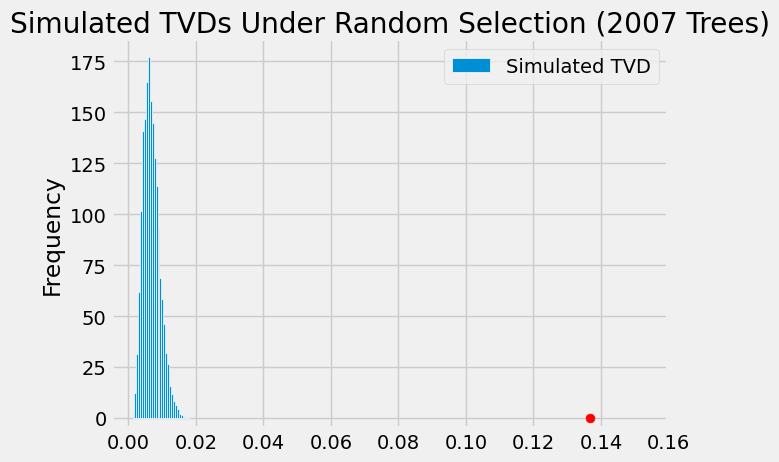

In [13]:
pd.DataFrame({'Simulated TVD': simulated_tvds}).plot.hist(
    density=True, bins=30, edgecolor='white')
plt.scatter(observed_tvd, 0, color='red', s=40, zorder=3)
plt.title('Simulated TVDs Under Random Selection (2007 Trees)')
plt.xlim(-0.005, 0.16)
plt.ylim(-5, None);

The histogram shows the distribution of 10,000 simulated TVD values under random selection. The simulated values cluster tightly between about 0.003 and 0.015. The red dot marks the observed TVD (~0.137), which is far to the right of all simulated values — completely outside the range of what random chance would produce. This provides very strong evidence that the 2007 species distribution was **not** consistent with random sampling from the without-2007 population. The 2007 sample was statistically different from the typical years.

#### Part 3: Tree Status and Elevation

The tree survey records if the tree was alive or dead. In this part, test if the difference in the elevation distribution of live and dead trees is simply due to chance. For this analysis you will use the full tree data (the `trees` DataFrame, not the data split for 2007.) Notice that this looks like the examples in Chapter 12.

14. Explore the data
- Plot two density histograms (overlaid) showing the elevation of live versus dead trees (choose an appropriate number of bins to convey the pattern)
- Interpret the graph

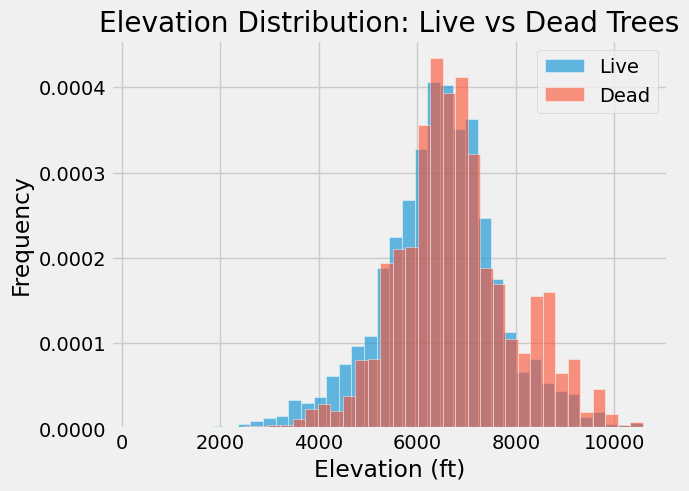

In [14]:
trees.loc[trees['tree_status_code_name'] == 'Live tree', 'elevation'].plot.hist(
    density=True, bins=40, edgecolor='white', alpha=0.6, label='Live')
trees.loc[trees['tree_status_code_name'] == 'Dead tree', 'elevation'].plot.hist(
    density=True, bins=40, edgecolor='white', alpha=0.6, label='Dead')
plt.legend()
plt.xlabel('Elevation (ft)')
plt.title('Elevation Distribution: Live vs Dead Trees');

Both distributions are roughly bell-shaped and centered around 6,000–7,000 ft elevation. However, the dead tree distribution is shifted slightly to the right (higher elevation) compared to the live tree distribution. Dead trees appear more concentrated at higher elevations, while live trees have a broader spread toward lower elevations. This suggests a potential relationship between elevation and tree mortality.

15. Use the `groupby` method to compute the mean elevation for dead trees and live trees
    - Hint: to match the style of the book, first create a new DataFrame with just the two columns needed for this analysis, then compute the `groupby` on that
    - Print the result
    - Does this result correspond to the histograms? Why?

In [15]:
status_elevation = trees[['tree_status_code_name', 'elevation']].copy()
mean_by_status = status_elevation.groupby('tree_status_code_name').mean()
print(mean_by_status)

                         elevation
tree_status_code_name             
Dead tree              6777.395539
Live tree              6445.731952


The mean elevation for dead trees (~6,777 ft) is higher than for live trees (~6,446 ft), a difference of about 332 ft. This corresponds to the histograms — the dead tree distribution was visibly shifted toward higher elevations.

16. Write out (in words) the null and alternative hypotheses. Hint: pick "lower" or "higher" based on the results of the previous two questions. 

**Null hypothesis:** The mean elevation of dead trees and live trees is the same. Any observed difference is due to random chance.

**Alternative hypothesis:** Dead trees have a **higher** mean elevation than live trees. The observed difference is not due to chance.

17. Create a function that takes a DataFrame and a group label as inputs, and returns the difference in the mean elevation between the groups.
    - Hint: go back to your null and alternative hypotheses to determine which value is subtracted from which
    - Run the function on the actual data and print the result
    - Does the output match the previous three questions? Explain.

In [16]:
def difference_of_means(df, group_label):
    grouped = df.groupby(group_label).mean()
    return grouped.loc['Dead tree', 'elevation'] - grouped.loc['Live tree', 'elevation']

observed_diff = difference_of_means(status_elevation, 'tree_status_code_name')
print('Observed difference (Dead - Live):', observed_diff)

Observed difference (Dead - Live): 331.6635870130076


The observed difference is approximately 331.66 ft (Dead minus Live), which is positive — consistent with the histograms and groupby results showing that dead trees are found at higher elevations on average.

18. Create and run a `for` loop that runs 1000 times and:
    - Randomly shuffles the dead and live tree labels
    - Computes the difference of means when the labels are shuffled
    - Stores the differences in list
    - Note: this might be slower than the textbook examples since the tree data is much larger
    - Note: no interpretation is needed for this question

In [17]:
simulated_diffs = []
for i in range(1000):
    shuffled = status_elevation.copy()
    shuffled['tree_status_code_name'] = np.random.permutation(shuffled['tree_status_code_name'].values)
    sim_diff = difference_of_means(shuffled, 'tree_status_code_name')
    simulated_diffs.append(sim_diff)
print(simulated_diffs[:10])

[np.float64(-3.5382386724286334), np.float64(-22.591812872167793), np.float64(12.704571340492294), np.float64(-4.407794645375361), np.float64(6.761702157617037), np.float64(5.820134870792572), np.float64(-6.745452243173531), np.float64(12.941511792604615), np.float64(8.834543955996196), np.float64(3.6373403135912667)]


19. Create a density histogram of the simulated differences (note: include `edgecolor` and a title). Interpret the result.

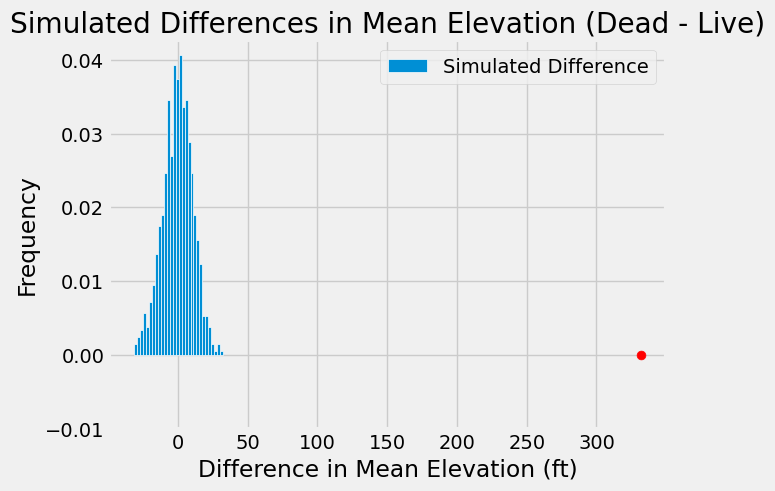

In [18]:
pd.DataFrame({'Simulated Difference': simulated_diffs}).plot.hist(
    density=True, bins=30, edgecolor='white')
plt.scatter(observed_diff, 0, color='red', s=40, zorder=3)
plt.title('Simulated Differences in Mean Elevation (Dead - Live)')
plt.xlabel('Difference in Mean Elevation (ft)')
plt.ylim(-0.01, None);

The simulated differences are centered around 0 and range roughly from about -30 to +30 ft. The observed difference of approximately 332 ft (red dot) is far to the right of all simulated values — it is not even close to the range of outcomes produced by random shuffling. This strongly suggests that the difference in mean elevation between dead and live trees is not due to chance.

20. Statistical significance
    - Compute the empirical p-value (Hint: when computing this recall your null and alternative hypotheses)
    - Interpret the result in statistical language and the practical implication for a regular person interested in Arizona trees (Note: do not speculate on "why" you got this result, just stick to the facts you have)

In [19]:
empirical_p = np.mean(np.array(simulated_diffs) >= observed_diff)
print('Empirical p-value:', empirical_p)

Empirical p-value: 0.0


The empirical p-value is 0.0, meaning that in 1,000 random permutations, none produced a difference as large as the observed 332 ft. We reject the null hypothesis at any conventional significance level (e.g., 0.05, 0.01). The data provide very strong evidence that dead trees in Arizona are found at statistically higher elevations than live trees. For someone interested in Arizona forests, this means tree mortality is not uniformly distributed across elevations — dead trees are disproportionately found at higher elevations.